#### Imports

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12,6)

#### Load Dataset

In [2]:
DATA_PATH = "..\\data\\cleaned_ai_stocks_task1.csv"

df = pd.read_csv(DATA_PATH)

df["Date"] = pd.to_datetime(df["Date"])

print(df.shape)

df.head()

(2109, 53)


,Date,AMD_Close,MSFT_Close,NVDA_Close,^IXIC_Close,AMD_High,MSFT_High,NVDA_High,^IXIC_High,AMD_Low,...,NVDA_Return_Capped,NVDA_Volume_Capped,^IXIC_Return,^IXIC_LogReturn,^IXIC_NormClose,^IXIC_MA20,^IXIC_MA50,^IXIC_Volatility20,^IXIC_Return_Capped,^IXIC_Volume_Capped
0,2018-01-02,10.98,78.699905,4.928265,7006.899902,11.02,79.029539,4.931973,7006.910156,10.34,...,NaN,355616000,NaN,NaN,100.000000,NaN,NaN,NaN,NaN,1929700000
1,2018-01-03,11.55,79.066162,5.252614,7065.529785,12.14,79.212669,5.283022,7069.149902,11.36,...,0.065814,914704000,0.008367,0.008333,100.836745,NaN,NaN,NaN,0.008367,2173130000
2,2018-01-04,12.12,79.762062,5.280303,7077.910156,12.43,80.265671,5.390561,7098.049805,11.97,...,0.005271,583268000,0.001752,0.001751,101.013433,NaN,NaN,NaN,0.001752,2103220000
3,2018-01-05,11.88,80.750946,5.325050,7136.560059,12.22,80.952390,5.362380,7137.040039,11.66,...,0.008474,580124000,0.008286,0.008252,101.850464,NaN,NaN,NaN,0.008286,2024000000
4,2018-01-08,12.28,80.833359,5.488214,7157.390137,12.30,81.108056,5.562378,7161.350098,11.85,...,0.030641,881216000,0.002919,0.002915,102.147743,NaN,NaN,NaN,0.002919,2055010000


#### Dataset Overview

In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 2109
Columns: 53
<class 'pandas.DataFrame'>
RangeIndex: 2109 entries, 0 to 2108
Data columns (total 53 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 2109 non-null   datetime64[us]
 1   AMD_Close            2109 non-null   float64       
 2   MSFT_Close           2109 non-null   float64       
 3   NVDA_Close           2109 non-null   float64       
 4   ^IXIC_Close          2109 non-null   float64       
 5   AMD_High             2109 non-null   float64       
 6   MSFT_High            2109 non-null   float64       
 7   NVDA_High            2109 non-null   float64       
 8   ^IXIC_High           2109 non-null   float64       
 9   AMD_Low              2109 non-null   float64       
 10  MSFT_Low             2109 non-null   float64       
 11  NVDA_Low             2109 non-null   float64       
 12  ^IXIC_Low            2109 non-null   float64       
 13  AMD_Open             

#### Statistical Summary

In [4]:
summary = df.describe()

summary

,Date,AMD_Close,MSFT_Close,NVDA_Close,^IXIC_Close,AMD_High,MSFT_High,NVDA_High,^IXIC_High,AMD_Low,...,NVDA_Return_Capped,NVDA_Volume_Capped,^IXIC_Return,^IXIC_LogReturn,^IXIC_NormClose,^IXIC_MA20,^IXIC_MA50,^IXIC_Volatility20,^IXIC_Return_Capped,^IXIC_Volume_Capped
count,2109,2109.000000,2109.000000,2109.000000,2109.000000,2109.000000,2109.000000,2109.000000,2109.000000,2109.000000,...,2108.000000,2.109000e+03,2108.000000,2108.000000,2109.000000,2090.000000,2060.000000,2089.000000,2108.000000,2.109000e+03
mean,2022-03-11 20:05:07.254623,97.648212,269.995064,51.256842,13351.020600,99.613224,272.516930,52.107733,13442.426000,95.587790,...,0.002254,4.146721e+08,0.000739,0.000628,190.541049,13321.166671,13286.247266,0.208946,0.000877,4.929155e+09
min,2018-01-02 00:00:00,9.530000,77.839203,3.150397,6192.919922,9.770000,79.029539,3.222290,6355.180176,9.040000,...,-0.066592,6.552850e+07,-0.123213,-0.131492,88.383165,6695.121021,6942.621406,0.070766,-0.027655,9.589500e+08
25%,2020-02-06 00:00:00,47.500000,151.874619,6.613819,8665.469727,48.299999,153.466983,6.715516,8745.820312,46.099998,...,-0.014913,2.566183e+08,-0.005906,-0.005924,123.670523,8747.896533,8774.724175,0.138035,-0.005906,3.089970e+09
50%,2022-03-10 00:00:00,90.910004,259.346741,18.891607,13036.429688,92.459999,261.282328,19.301289,13149.549805,89.029999,...,0.002785,3.896420e+08,0.001301,0.001300,186.051319,13185.501831,13179.020625,0.182248,0.001301,4.677520e+09
75%,2024-04-16 00:00:00,132.500000,389.478271,88.913818,16195.809570,136.389999,392.993856,90.594873,16309.019531,129.100006,...,0.019540,5.284020e+08,0.008593,0.008557,231.140873,16143.495227,16073.191118,0.254933,0.008593,5.950950e+09
max,2026-05-22 00:00:00,467.510010,538.658569,235.740005,26635.220703,481.410004,551.048474,236.539993,26707.140625,461.709991,...,0.071219,9.360776e+08,0.121632,0.114784,380.128460,25750.547168,23926.851445,0.944462,0.030342,1.024242e+10
std,NaN,65.690306,126.623972,61.272388,4843.438867,67.046485,127.571120,62.203508,4866.350428,64.056424,...,0.028623,1.950099e+08,0.014826,0.014853,69.123848,4759.298986,4656.317952,0.112752,0.012575,2.288552e+09


In [5]:
analysis_df = df[
    [
        "Date",

        "NVDA_Close",
        "MSFT_Close",
        "AMD_Close",
        "^IXIC_Close",

        "NVDA_Return",
        "MSFT_Return",
        "AMD_Return",
        "^IXIC_Return"
    ]
]

analysis_df.head()

,Date,NVDA_Close,MSFT_Close,AMD_Close,^IXIC_Close,NVDA_Return,MSFT_Return,AMD_Return,^IXIC_Return
0,2018-01-02,4.928265,78.699905,10.98,7006.899902,NaN,NaN,NaN,NaN
1,2018-01-03,5.252614,79.066162,11.55,7065.529785,0.065814,0.004654,0.051913,0.008367
2,2018-01-04,5.280303,79.762062,12.12,7077.910156,0.005271,0.008801,0.049351,0.001752
3,2018-01-05,5.325050,80.750946,11.88,7136.560059,0.008474,0.012398,-0.019802,0.008286
4,2018-01-08,5.488214,80.833359,12.28,7157.390137,0.030641,0.001021,0.033670,0.002919


#### Growth Comparision

In [6]:
growth_df = analysis_df.copy()

for stock in ["NVDA","MSFT","AMD","^IXIC"]:

    growth_df[f"{stock}_Growth"] = (
        growth_df[f"{stock}_Close"] /
        growth_df[f"{stock}_Close"].iloc[0]
    ) * 100

growth_df.head()

,Date,NVDA_Close,MSFT_Close,AMD_Close,^IXIC_Close,NVDA_Return,MSFT_Return,AMD_Return,^IXIC_Return,NVDA_Growth,MSFT_Growth,AMD_Growth,^IXIC_Growth
0,2018-01-02,4.928265,78.699905,10.98,7006.899902,NaN,NaN,NaN,NaN,100.000000,100.000000,100.000000,100.000000
1,2018-01-03,5.252614,79.066162,11.55,7065.529785,0.065814,0.004654,0.051913,0.008367,106.581422,100.465384,105.191263,100.836745
2,2018-01-04,5.280303,79.762062,12.12,7077.910156,0.005271,0.008801,0.049351,0.001752,107.143243,101.349629,110.382517,101.013433
3,2018-01-05,5.325050,80.750946,11.88,7136.560059,0.008474,0.012398,-0.019802,0.008286,108.051226,102.606154,108.196727,101.850464
4,2018-01-08,5.488214,80.833359,12.28,7157.390137,0.030641,0.001021,0.033670,0.002919,111.361990,102.710872,111.839711,102.147743


#### Growth Trend Visualization

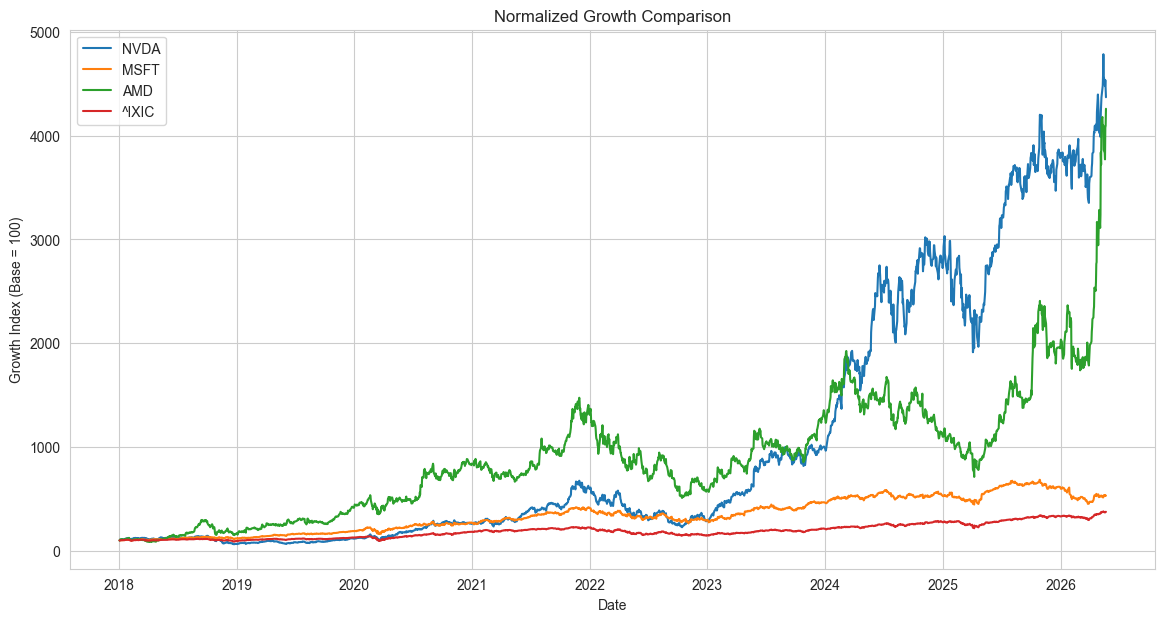

In [7]:
plt.figure(figsize=(14,7))

for stock in ["NVDA","MSFT","AMD","^IXIC"]:

    plt.plot(
        growth_df["Date"],
        growth_df[f"{stock}_Growth"],
        label=stock
    )

plt.title("Normalized Growth Comparison")
plt.xlabel("Date")
plt.ylabel("Growth Index (Base = 100)")
plt.legend()

plt.show()

#### Total Return Calculation

In [8]:
returns = {}

for stock in ["NVDA","MSFT","AMD","^IXIC"]:

    start_price = analysis_df[f"{stock}_Close"].iloc[0]
    end_price = analysis_df[f"{stock}_Close"].iloc[-1]

    total_return = (
        (end_price - start_price)
        / start_price
    ) * 100

    returns[stock] = total_return

returns_df = pd.DataFrame(
    returns.items(),
    columns=["Stock","Total Return (%)"]
)

returns_df

,Stock,Total Return (%)
0,NVDA,4269.286524
1,MSFT,431.855795
2,AMD,4157.832689
3,^IXIC,275.971843


#### Total Return Visualization

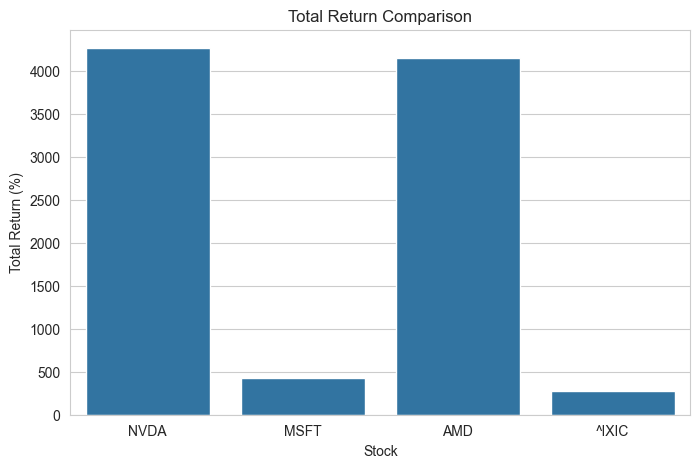

In [9]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=returns_df,
    x="Stock",
    y="Total Return (%)"
)

plt.title("Total Return Comparison")

plt.show()

#### Daily Return Distribution

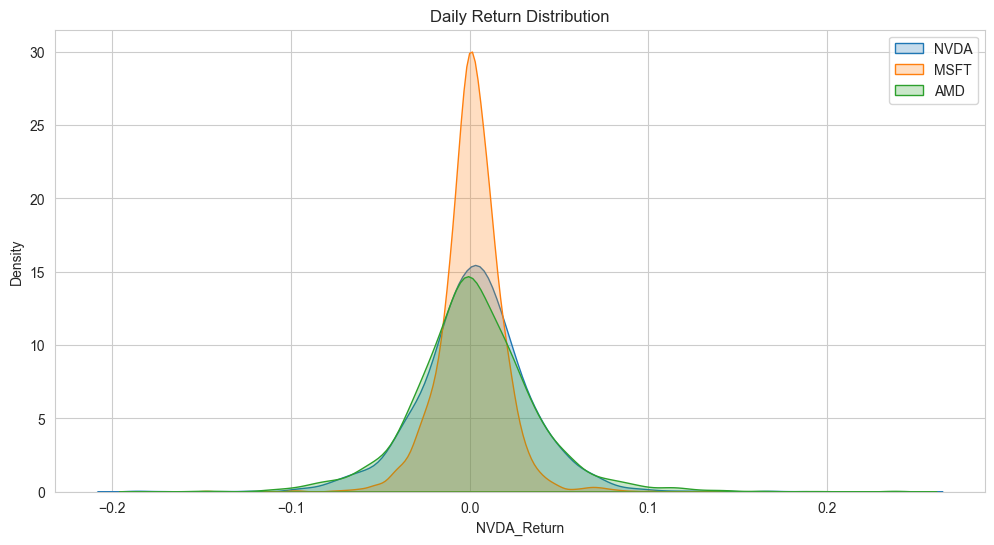

In [10]:
plt.figure(figsize=(12,6))

sns.kdeplot(
    analysis_df["NVDA_Return"],
    fill=True,
    label="NVDA"
)

sns.kdeplot(
    analysis_df["MSFT_Return"],
    fill=True,
    label="MSFT"
)

sns.kdeplot(
    analysis_df["AMD_Return"],
    fill=True,
    label="AMD"
)

plt.legend()

plt.title("Daily Return Distribution")

plt.show()

#### Volatility Analysis

In [11]:
volatility = pd.DataFrame({

    "Stock":["NVDA","MSFT","AMD","NASDAQ"],

    "Volatility":[

        analysis_df["NVDA_Return"].std(),

        analysis_df["MSFT_Return"].std(),

        analysis_df["AMD_Return"].std(),

        analysis_df["^IXIC_Return"].std()
    ]
})

volatility

,Stock,Volatility
0,NVDA,0.031942
1,MSFT,0.017959
2,AMD,0.035332
3,NASDAQ,0.014826


#### Volatility Visualization

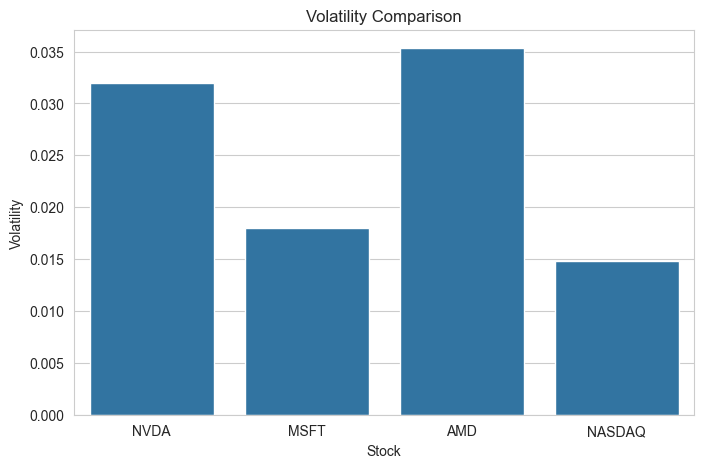

In [12]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=volatility,
    x="Stock",
    y="Volatility"
)

plt.title("Volatility Comparison")

plt.show()

#### Correlation Matrix

In [13]:
corr_df = analysis_df[
    [
        "NVDA_Return",
        "MSFT_Return",
        "AMD_Return",
        "^IXIC_Return"
    ]
]

corr = corr_df.corr()

corr

,NVDA_Return,MSFT_Return,AMD_Return,^IXIC_Return
NVDA_Return,1.000000,0.646512,0.666483,0.785269
MSFT_Return,0.646512,1.000000,0.517699,0.836851
AMD_Return,0.666483,0.517699,1.000000,0.669680
^IXIC_Return,0.785269,0.836851,0.669680,1.000000


#### Correlation Heatmap

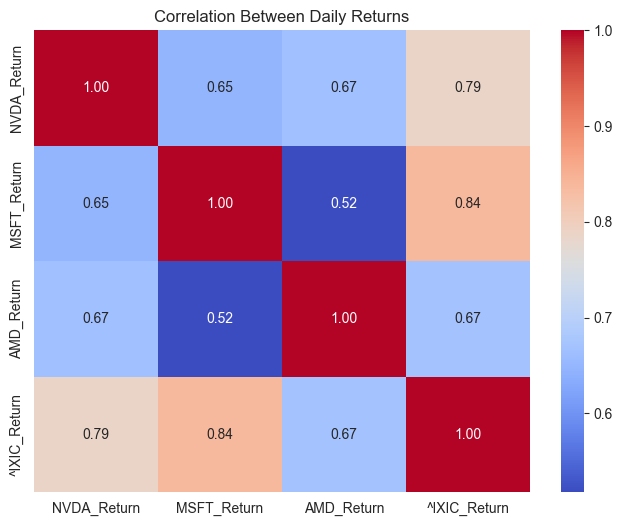

In [14]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Daily Returns")

plt.show()

#### Relationship Between NVDA and NASDAQ

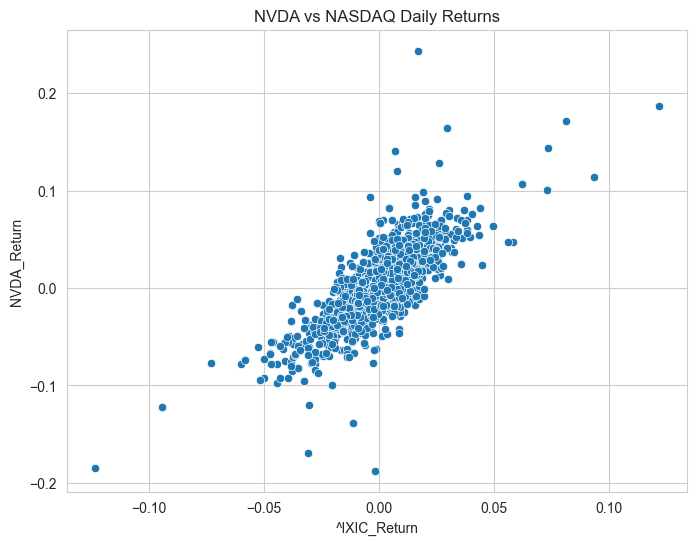

In [15]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=analysis_df["^IXIC_Return"],
    y=analysis_df["NVDA_Return"]
)

plt.title("NVDA vs NASDAQ Daily Returns")

plt.show()

#### Monthly Performance Analysis

In [16]:
monthly_df = analysis_df.copy()

monthly_df["YearMonth"] = (
    monthly_df["Date"]
    .dt.to_period("M")
)

monthly_returns = (
    monthly_df
    .groupby("YearMonth")
    [["NVDA_Return"]]
    .mean()
)

monthly_returns.head()

,NVDA_Return
YearMonth,
2018-01,0.010695
2018-02,-0.000168
2018-03,-0.001629
2018-04,-0.001082
2018-05,0.005392


#### Monthly Trend

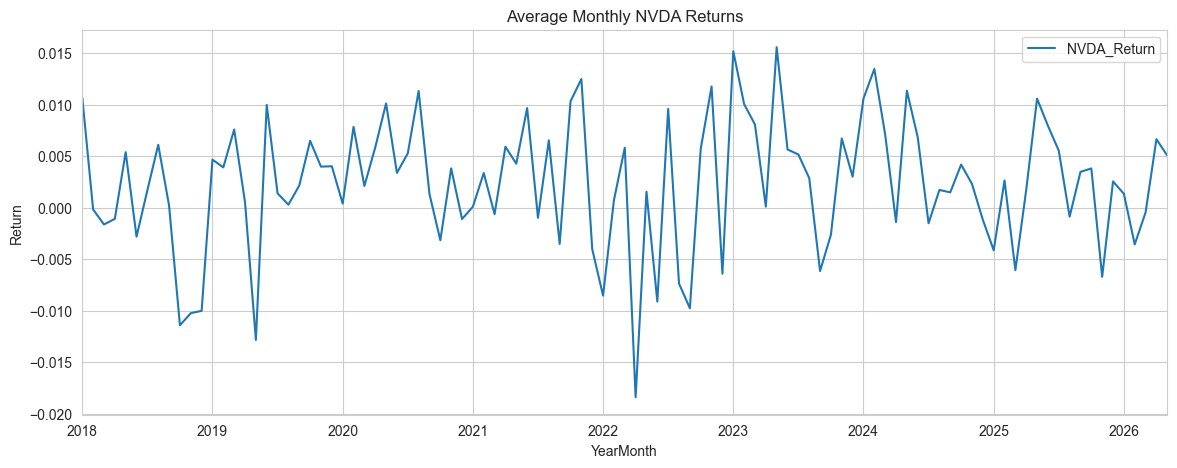

In [17]:
monthly_returns.plot(
    figsize=(14,5)
)

plt.title("Average Monthly NVDA Returns")

plt.ylabel("Return")

plt.show()

#### AI Boom Analysis (Pre vs Post ChatGPT)

In [18]:
chatgpt_date = pd.Timestamp("2022-11-30")

pre_ai = analysis_df[
    analysis_df["Date"] < chatgpt_date
]

post_ai = analysis_df[
    analysis_df["Date"] >= chatgpt_date
]

print("Pre AI Period:", len(pre_ai))
print("Post AI Period:", len(post_ai))

Pre AI Period: 1237
Post AI Period: 872


#### Compare NVDA Performance

In [19]:
pre_return = (
    pre_ai["NVDA_Close"].iloc[-1]
    /
    pre_ai["NVDA_Close"].iloc[0]
    - 1
) * 100

post_return = (
    post_ai["NVDA_Close"].iloc[-1]
    /
    post_ai["NVDA_Close"].iloc[0]
    - 1
) * 100

comparison = pd.DataFrame({

    "Period":[
        "Pre ChatGPT",
        "Post ChatGPT"
    ],

    "NVDA Return %":[
        pre_return,
        post_return
    ]
})

comparison

,Period,NVDA Return %
0,Pre ChatGPT,216.917231
1,Post ChatGPT,1173.753189


#### AI Impact Visualization

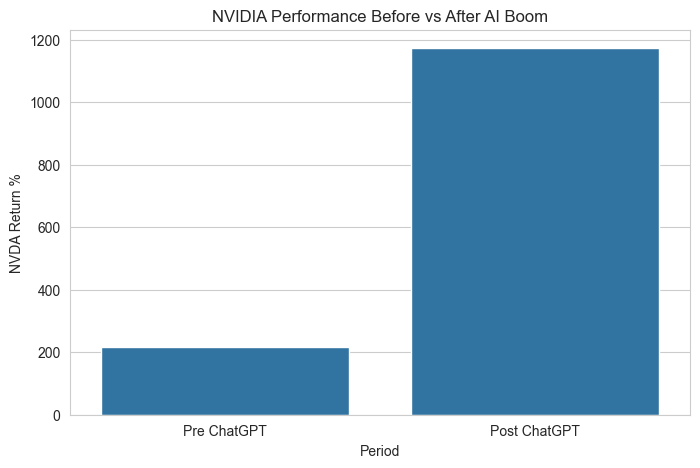

In [20]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Period",
    y="NVDA Return %"
)

plt.title("NVIDIA Performance Before vs After AI Boom")

plt.show()

#### Identify Best Performing Asset

In [21]:
best_stock = returns_df.sort_values(
    "Total Return (%)",
    ascending=False
)

best_stock

,Stock,Total Return (%)
0,NVDA,4269.286524
2,AMD,4157.832689
1,MSFT,431.855795
3,^IXIC,275.971843


#### Key Insights Table

In [22]:
insights = pd.DataFrame({

    "Metric":[

        "Best Performer",

        "Most Volatile",

        "Strongest Correlation with NASDAQ"
    ],

    "Result":[

        returns_df.sort_values(
            "Total Return (%)",
            ascending=False
        ).iloc[0]["Stock"],

        volatility.sort_values(
            "Volatility",
            ascending=False
        ).iloc[0]["Stock"],

        corr["^IXIC_Return"]
        .drop("^IXIC_Return")
        .idxmax()
    ]
})

insights

,Metric,Result
0,Best Performer,NVDA
1,Most Volatile,AMD
2,Strongest Correlation with NASDAQ,MSFT_Return


#### Save EDA Outputs

In [23]:
returns_df.to_csv(
    "../reports/eda/eda_returns_summary.csv",
    index=False
)

volatility.to_csv(
    "../reports/eda/eda_volatility_summary.csv",
    index=False
)

insights.to_csv(
    "../reports/eda/eda_key_insights.csv",
    index=False
)

print("EDA reports saved")

EDA reports saved


#### EDA Conclusion

The exploratory analysis shows that the AI-driven market expansion strongly favored NVIDIA over the full period, with AMD also outperforming the broader technology benchmark. Microsoft delivered steadier growth, while NASDAQ provided the lower-volatility reference point for comparison.

Key takeaways:

1. NVIDIA was the strongest long-term growth story across the AI-related stocks.
2. The highest total return and strongest momentum were concentrated in the AI leaders, especially NVIDIA and AMD.
3. AMD showed the highest risk profile, while Microsoft remained comparatively more stable.
4. Daily returns for the stocks were positively related to NASDAQ, confirming a broader technology-market linkage.
5. Post-ChatGPT performance improved materially for NVIDIA, supporting the view that the AI boom accelerated investor interest in the sector.

Overall, the analysis provides evidence of how major technology stocks responded during the AI expansion era and highlights the separation between AI beneficiaries and the wider benchmark.